[dataset](https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records) from UCI repo

In [1]:
import pandas as pd
import numpy as np
from scipy.io import arff
import warnings
warnings.filterwarnings(action='ignore')
# 데이터 전처리
from sklearn.model_selection import train_test_split

# 모델 패키지
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 모델 평가
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

matplotlib.rcParams['axes.unicode_minus'] = False
plt.rc('font', family='applegothic')

In [2]:
data = pd.read_csv("/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/wine+quality/winequality-red.csv",sep=';')

# arff dataset load
file_path = '/Users/basamg/Project_kw/2025_2/ai_app/anomaly_detect/data/bank-additional-ful-nominal.arff'

try:
    data, meta_data = arff.loadarff(file_path)
    data = pd.DataFrame(data)
    for col in data.select_dtypes(['object']).columns: # 2진수 decode 필수
        data[col] = data[col].str.decode('utf-8')

except FileNotFoundError as e:
    print(e)
except Exception as e:
    print(e)

In [3]:
print("data 갯수 :\t",len(data))
print("feature 갯수 :\t", len(data.columns))
data.head()

data 갯수 :	 1599
feature 갯수 :	 12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
# for heart disease data
# wine quality score for 0 to 10
print(data['quality'].value_counts())

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


In [6]:
# 데이터 전처리
data_modi = data.copy()
data_modi.loc[data['quality'] <= 5 ,'quality'] = 1
data_modi.loc[data['quality'] > 5,'quality'] = 0


target = data_modi['quality']
print(target.value_counts())

quality
0    855
1    744
Name: count, dtype: int64


In [7]:
data_modi[data_modi['quality']==1]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,1
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1582,6.1,0.715,0.10,2.6,0.053,13.0,27.0,0.99362,3.57,0.50,11.9,1
1583,6.2,0.460,0.29,2.1,0.074,32.0,98.0,0.99578,3.33,0.62,9.8,1
1589,6.6,0.725,0.20,7.8,0.073,29.0,79.0,0.99770,3.29,0.54,9.2,1
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,1


In [8]:
data_modi_1 = data_modi.iloc[data_modi[(data_modi['quality']==1)].sample(frac=0.2).index]
data_modi_0 = data_modi[data_modi['quality']==0]

data_modi = pd.concat([data_modi_1, data_modi_0], ignore_index=True)
target = data_modi['quality']
print(target.value_counts())

quality
0    855
1    149
Name: count, dtype: int64


In [9]:
data_modi_1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
313,8.6,0.470,0.30,3.0,0.076,30.0,135.0,0.99760,3.30,0.53,9.4,1
322,7.8,0.620,0.05,2.3,0.079,6.0,18.0,0.99735,3.29,0.63,9.3,1
409,12.5,0.460,0.49,4.5,0.070,26.0,49.0,0.99810,3.05,0.57,9.6,1
785,9.9,0.350,0.41,2.3,0.083,11.0,61.0,0.99820,3.21,0.50,9.5,1
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
987,7.1,0.360,0.30,1.6,0.080,35.0,70.0,0.99693,3.44,0.50,9.4,1
1423,6.4,0.530,0.09,3.9,0.123,14.0,31.0,0.99680,3.50,0.67,11.0,1
88,9.3,0.390,0.44,2.1,0.107,34.0,125.0,0.99780,3.14,1.22,9.5,1
973,8.5,0.340,0.44,1.7,0.079,6.0,12.0,0.99605,3.52,0.63,10.7,1


<Axes: xlabel='fixed acidity', ylabel='volatile acidity'>

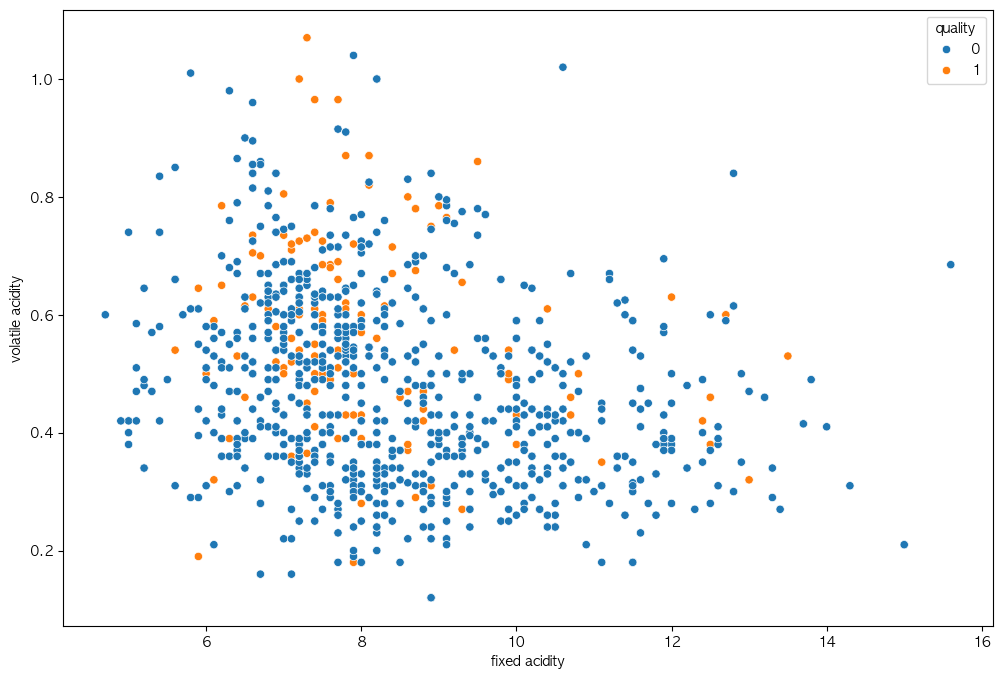

In [10]:
plt.figure(figsize=(12,8))
sns.scatterplot(x='fixed acidity', y='volatile acidity', hue='quality', data=data_modi)

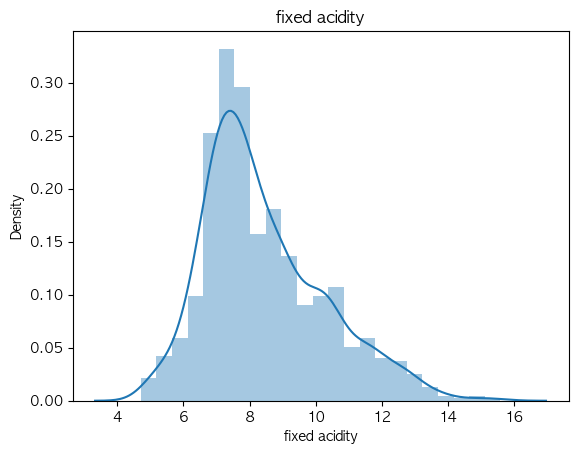

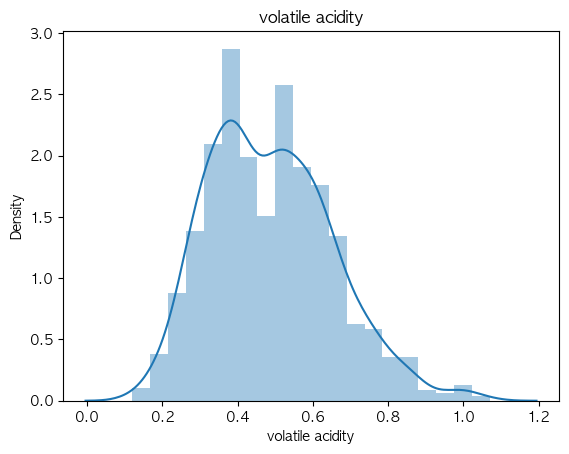

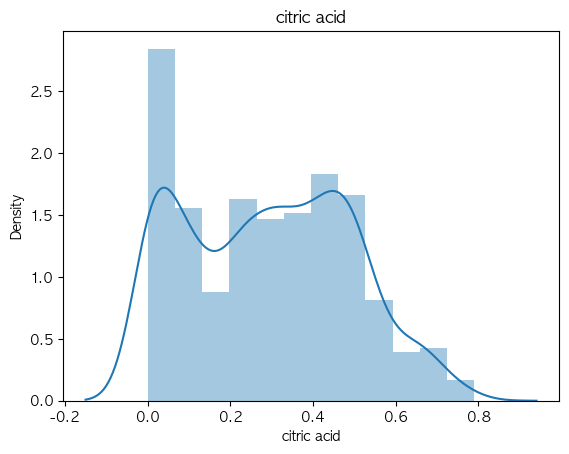

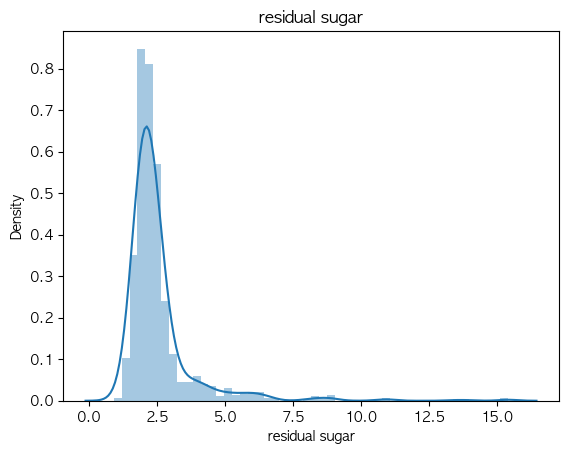

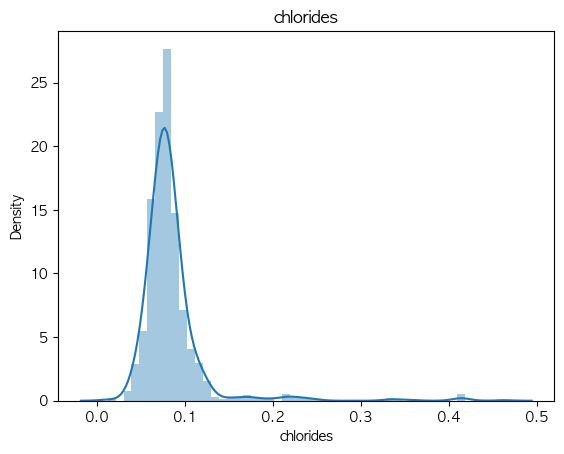

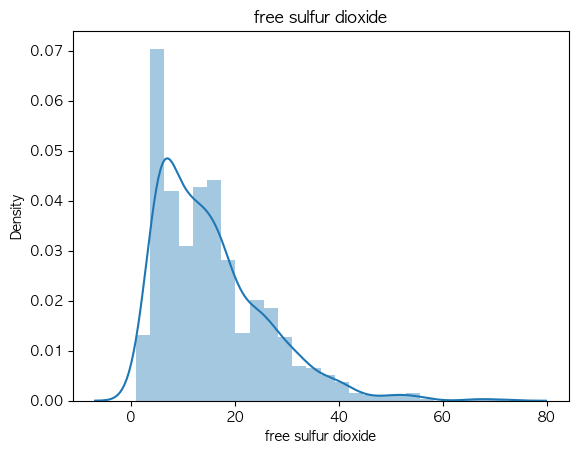

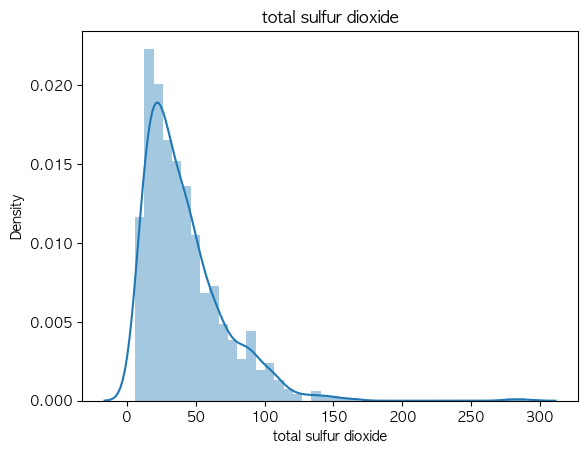

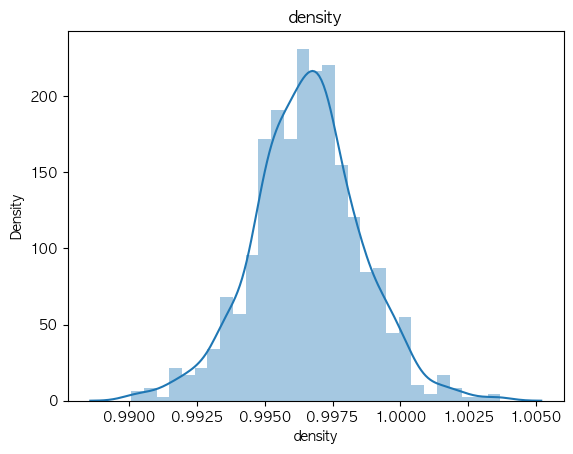

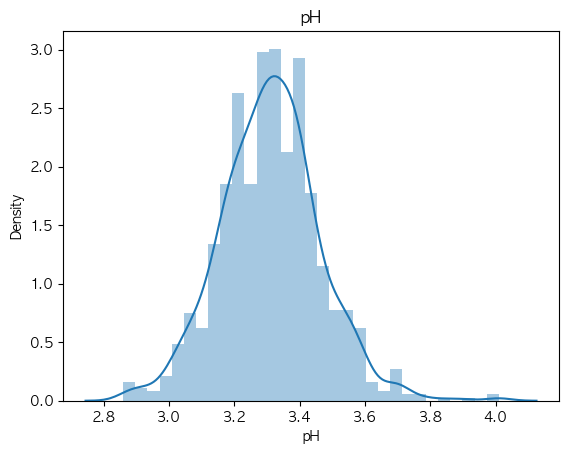

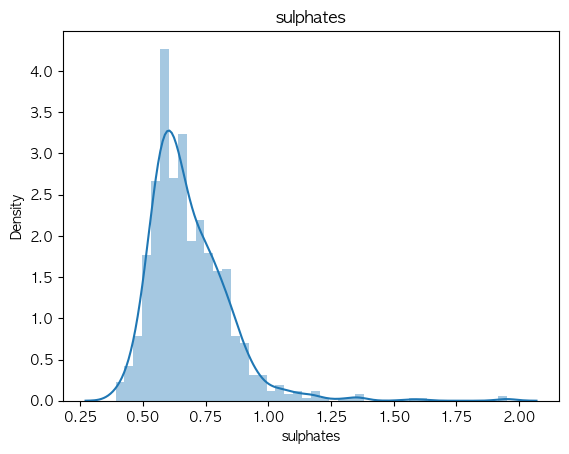

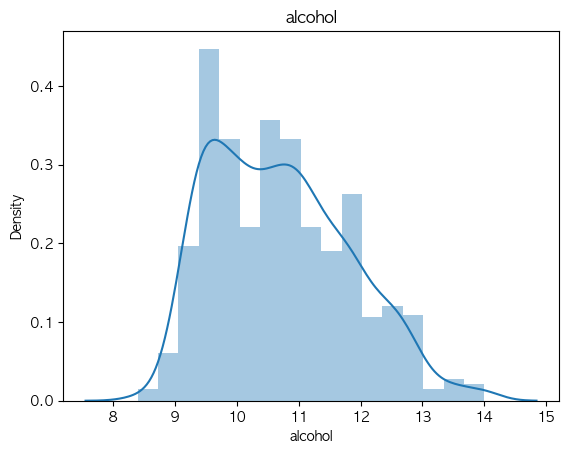

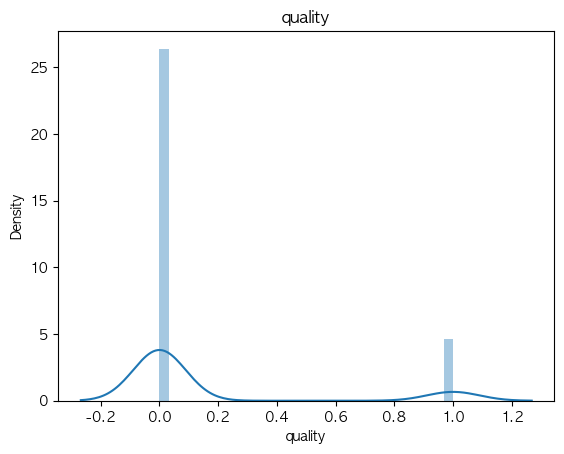

In [11]:
for col in data_modi:
    sns.distplot(data_modi.loc[data[col].notnull(), col])
    plt.title(col)
    plt.show()

quality
0    855
1    149
Name: count, dtype: int64


<Axes: title={'center': 'class distribution'}, xlabel='count', ylabel='quality'>

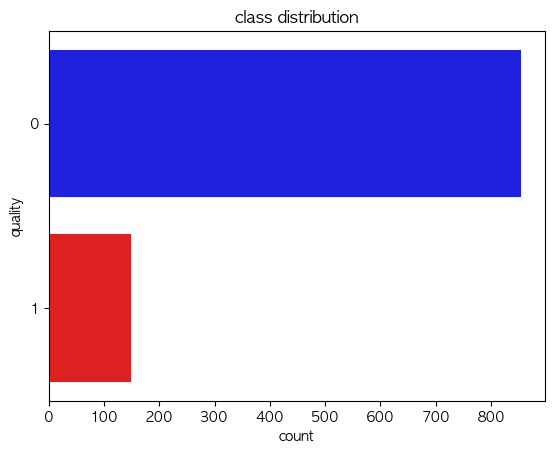

In [12]:
print(target.value_counts())
plt.title("class distribution")
sns.countplot(y=data_modi['quality'], data=data_modi, palette=['blue','red'])

In [13]:
x = data_modi[data_modi.columns.difference(['quality'])]
y = data_modi['quality']
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [14]:
len(x_test)

201

In [15]:
y_test.value_counts()

quality
0    175
1     26
Name: count, dtype: int64

In [16]:
# 명목형 변수 : anaemia diabetes high_blood_pressure serum_creatinine sex smoking - 0 or 1
# time : follow-up perioud
x

,alcohol,chlorides,citric acid,density,fixed acidity,free sulfur dioxide,pH,residual sugar,sulphates,total sulfur dioxide,volatile acidity
0,9.4,0.076,0.30,0.99760,8.6,30.0,3.30,3.0,0.53,135.0,0.470
1,9.3,0.079,0.05,0.99735,7.8,6.0,3.29,2.3,0.63,18.0,0.620
2,9.6,0.070,0.49,0.99810,12.5,26.0,3.05,4.5,0.57,49.0,0.460
3,9.5,0.083,0.41,0.99820,9.9,11.0,3.21,2.3,0.50,61.0,0.350
4,10.2,0.075,0.12,0.99547,5.9,32.0,3.57,2.0,0.71,44.0,0.645
...,...,...,...,...,...,...,...,...,...,...,...
999,11.0,0.076,0.13,0.99574,6.3,29.0,3.42,2.3,0.75,40.0,0.510
1000,9.5,0.068,0.08,0.99651,6.8,28.0,3.42,1.9,0.82,38.0,0.620
1001,11.2,0.062,0.10,0.99512,5.9,39.0,3.52,2.2,0.76,51.0,0.550
1002,11.0,0.076,0.13,0.99574,6.3,29.0,3.42,2.3,0.75,40.0,0.510


In [76]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train, x_test, y_train, y_test = train_test_split(x ,y, test_size=0.2, random_state=42)

x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

x_test_sc = pd.DataFrame(x_test_sc,columns=x.columns)
x_train_sc = pd.DataFrame(x_train_sc,columns=x.columns)

# PCA
- std 가 큰 변수에 영향을 받는다 → scaling

In [77]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(x_train_sc)

PCA_pred_train = pca.transform(x_train_sc)
result = pca.transform(x_test_sc)
print(pca.explained_variance_ratio_)
result =pd.DataFrame(result, columns=['feature1', 'feature2'])

[0.28957299 0.16575306]


In [78]:
result

,feature1,feature2
0,-2.345254,0.662787
1,0.881176,-1.088755
2,0.922329,-1.398537
3,-0.363599,0.235988
4,-1.476857,0.452846
...,...,...
196,3.781923,-0.903398
197,0.991024,-1.989487
198,0.723302,-1.079249
199,2.301940,-1.395842


In [79]:
y_train.value_counts()

quality
0    680
1    123
Name: count, dtype: int64

In [80]:
y_test.value_counts()

quality
0    175
1     26
Name: count, dtype: int64

In [81]:
y_test_reset_index = y_test.reset_index(drop=True)
y_test_reset_index

0      0
1      0
2      0
3      0
4      0
      ..
196    0
197    0
198    0
199    0
200    0
Name: quality, Length: 201, dtype: int64

In [82]:
result['label'] = y_test_reset_index
result

,feature1,feature2,label
0,-2.345254,0.662787,0
1,0.881176,-1.088755,0
2,0.922329,-1.398537,0
3,-0.363599,0.235988,0
4,-1.476857,0.452846,0
...,...,...,...
196,3.781923,-0.903398,0
197,0.991024,-1.989487,0
198,0.723302,-1.079249,0
199,2.301940,-1.395842,0


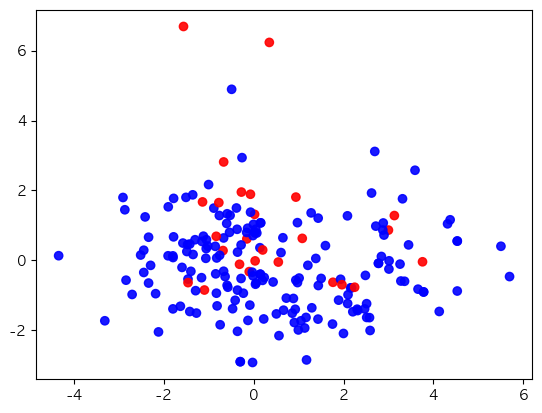

In [83]:
color_map = {0:'blue', 1:'red'}
colors = result['label'].map(color_map)
plt.scatter(x=result['feature1'], y=result['feature2'], c = colors, alpha=0.9)

In [90]:
# 재구성 기반은 이상치는 다시 복구가 안될 것이다 라는 전제

# x_train 을 통해서 x_proj 를 계산, 이후에 threshold 설정
x_proj = pca.inverse_transform(pca.transform(x_train_sc))
recon_error = ( (x_train_sc - x_proj) **2 ).sum(axis=1)
recon_error = pd.DataFrame(recon_error,columns=['error']).sort_values(by='error',ascending=False)
thre = np.percentile(recon_error, 90)

x_proj = pca.inverse_transform(pca.transform(x_test_sc))
recon_error = ( (x_test_sc - x_proj) **2 ).sum(axis=1)
pred_pca = (recon_error >= thre).astype(int)
pred_pca

print(classification_report(y.loc[x_test_sc.index], pred_pca, digits=3))

              precision    recall  f1-score   support

           0      0.244     0.846     0.379        52
           1      0.619     0.087     0.153       149

    accuracy                          0.284       201
   macro avg      0.432     0.467     0.266       201
weighted avg      0.522     0.284     0.212       201



# KNN

In [92]:
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', algorithm='auto', metric='minkowski')
knn.fit(x_train_sc, y_train)

KNeighborsClassifier(weights='distance')

In [93]:
knn_pred_train = knn.predict(x_train_sc)
knn_pred_test = knn.predict(x_test_sc)

print(metrics.accuracy_score(y_train, knn_pred_train))
print(metrics.accuracy_score(y_test, knn_pred_test))

print(classification_report(y_test, knn_pred_test, digits=3))

1.0
0.8656716417910447
              precision    recall  f1-score   support

           0      0.885     0.971     0.926       175
           1      0.444     0.154     0.229        26

    accuracy                          0.866       201
   macro avg      0.665     0.563     0.578       201
weighted avg      0.828     0.866     0.836       201



[[170   5]
 [ 22   4]]


<Axes: >

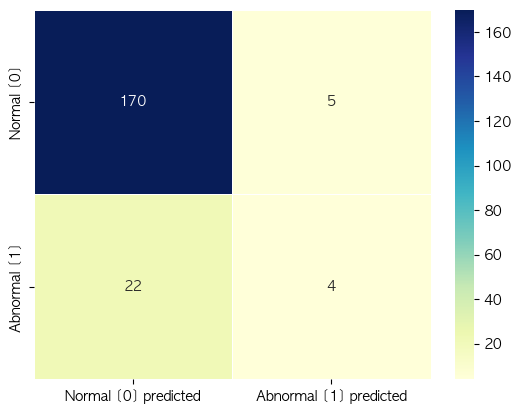

In [94]:
cm = confusion_matrix(y_test, knn_pred_test)

# col : 모델 예측 
# raw : 실제
print(cm)

sns.heatmap(pd.DataFrame(cm, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# KMeans

In [166]:
x = data_modi[data_modi.columns.difference(['quality'])]
y = data_modi['quality']
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)


ssd = []
for num in range(2, 11):
    km = KMeans(n_clusters=num, init='k-means++', random_state=42, n_init=10)
    km.fit(x_train_sc)
    ssd.append(km.inertia_)

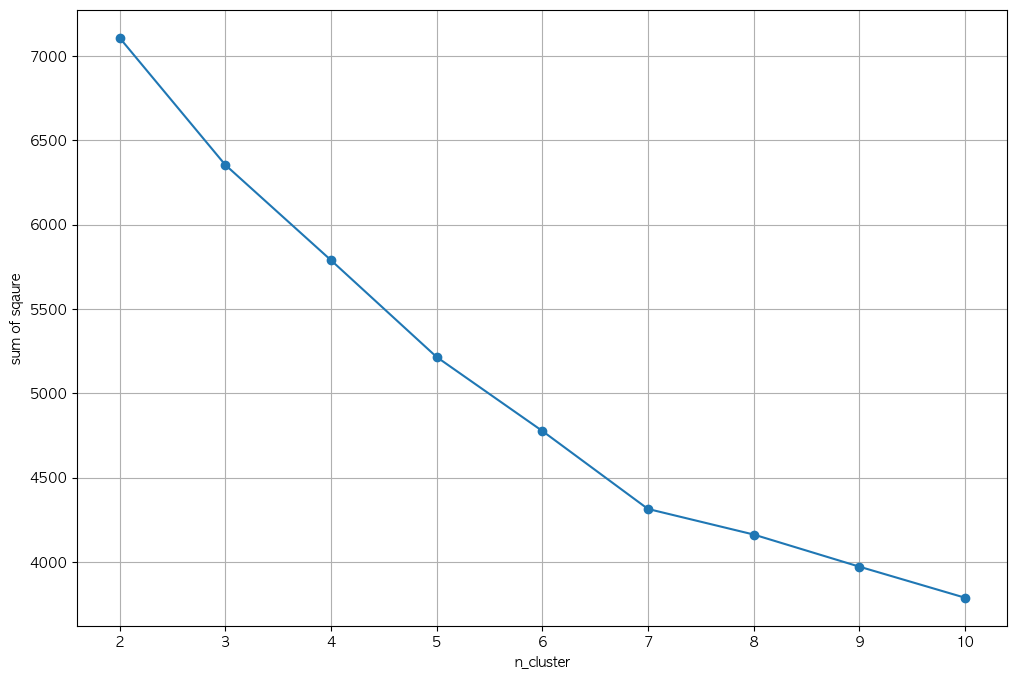

In [102]:
plt.figure(figsize=(12,8))
plt.plot(range(2,11), ssd, marker='o')
plt.xlabel('n_cluster')
plt.ylabel('sum of sqaure')
plt.xticks(range(2,11))
plt.grid()
plt.show()

In [168]:
km = KMeans(n_clusters=7)
model = km.fit(x_train)

In [169]:
def distance_from_center(input_data:pd.DataFrame, predict:pd.DataFrame, y):
    center = model.cluster_centers_[predict]
    dist = ((center-input_data)**2).sum(axis=1) # center 와 input_data 빼고 제곱하고 
    return np.round(dist, 3)

In [170]:
dist = distance_from_center(x_train, model.predict(x_train), y_test)
y_pred_train = model.predict(x_train)
x_train['pred'] = y_pred_train # 예측 군집 할당
x_train['dist'] = dist # 군집 중심과의 거리

dist = distance_from_center(x_test, model.predict(x_test), y_test)
y_pred_test = model.predict(x_test)
x_test['dist'] = dist
x_test['pred'] = y_pred_test

In [171]:
# 24개 test data 에 대해 3개 이상치 데이터로 선정
#outlier_idx = list(x_test.sort_values('dist',ascending=False).head(10).index)

# 2nd way, set the threshold
# threshold = np.percentile(x_test['dist'], 90)

threshold = np.percentile(x_train['dist'], 90)
print(threshold)

out_lier = x_test[x_test['dist'] > threshold]
data.loc[out_lier.index]

185.03920000000002


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
767,7.5,0.600,0.32,2.70,0.103,13.0,98.0,0.99938,3.45,0.62,9.5,5
605,8.3,0.600,0.13,2.60,0.085,6.0,24.0,0.99840,3.31,0.59,9.2,6
158,7.1,0.680,0.00,2.20,0.073,12.0,22.0,0.99690,3.48,0.50,9.3,5
809,7.6,0.480,0.31,2.80,0.070,4.0,15.0,0.99693,3.22,0.55,10.3,6
500,7.8,0.520,0.25,1.90,0.081,14.0,38.0,0.99840,3.43,0.65,9.0,6
107,6.2,0.630,0.31,1.70,0.088,15.0,64.0,0.99690,3.46,0.79,9.3,5
929,8.7,0.330,0.38,3.30,0.063,10.0,19.0,0.99468,3.30,0.73,12.0,7
277,11.5,0.180,0.51,4.00,0.104,4.0,23.0,0.99960,3.28,0.97,10.1,6
904,6.8,0.590,0.06,6.00,0.060,11.0,18.0,0.99620,3.41,0.59,10.8,7
548,12.4,0.350,0.49,2.60,0.079,27.0,69.0,0.99940,3.12,0.75,10.4,6


In [184]:
out_lier.index

Index([767, 605, 158, 809, 500, 107, 929, 277, 904, 548, 136, 828, 999,  55,
       394, 299, 541, 596, 781, 432, 137, 594],
      dtype='int64')

In [185]:
y_pred_test = pd.DataFrame(y_pred_test, index=x_test.index)
y_pred_test.loc[out_lier.index] = 1
y_pred_test.loc[out_lier.index]

,0
767,1
605,1
158,1
809,1
500,1
107,1
929,1
277,1
904,1
548,1


In [186]:
not_out_lier_idx= ~y_pred_test.index.isin(out_lier.index)
y_pred_test.loc[not_out_lier_idx] = 0

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       179
           1       0.15      0.18      0.17        22

    accuracy                           0.80       201
   macro avg       0.53      0.53      0.53       201
weighted avg       0.82      0.80      0.81       201



<Axes: >

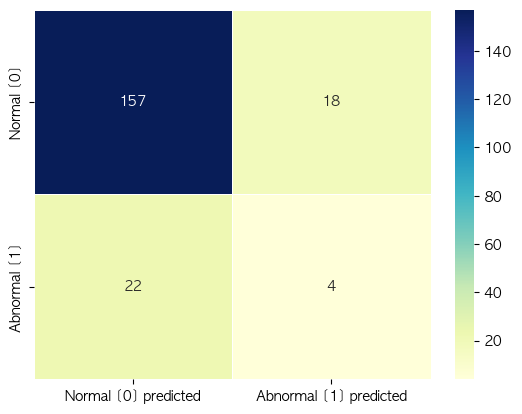

In [191]:
print(classification_report(y_pred_test, y_test))

# dist 가 threshold 보다 큰 outlier 데이터에 대한
# model predict 결과와
# 실제 y_test 
con_mat = confusion_matrix(y_true=y_test, y_pred=y_pred_test)


sns.heatmap(pd.DataFrame(con_mat, columns = ['normal [0]', 'abnormal [1]']),
            xticklabels=['Normal [0] predicted', 'Abnormal [1] predicted'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

# GMM

- bic 를 통해 모델이 데이터를 얼마나 설명하는가를 판단
- covariance type 을 통해서 공분산 행렬의 형태를 가정 → 이를 통해, mixture 하는 가우시안 분포들이 어떻게 생겼는가를 가정
     - spherical : 모든 공분산이 같은 모양 같은 크기
     - diagonal : 공분산행렬이 대각행렬만 존재, 클러스터의 크기가 다를 수 있음
     - tied : 모양 크기 방향이 같지면 타원형일 수 있음
     - full : 자유자재

In [194]:
x = data_modi[data_modi.columns.difference(['quality'])]
y = data_modi['quality']
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

from sklearn.mixture import GaussianMixture
best_bic = np.inf
bic = []
cov_type = ["spherical", "diag", "tied", "full"]
n_components_range = range(2,11)

for type in cov_type:
    for n_components in n_components_range:
        mog = GaussianMixture(
            n_components=n_components, covariance_type=type
        )
        mog.fit(x_train)
        bic.append(mog.bic(x_train))
        if bic[-1] < best_bic:
            best_bic = bic[-1]
            best_mog = mog

In [195]:
print(best_mog.covariance_type)
print(best_mog.n_components)

full
3


In [196]:
mog_test_pred = best_mog.predict(x_test)
mog_test_pred = pd.DataFrame(mog_test_pred)
mog_test_pred = mog_test_pred.replace({0:0, 1:0, 2:1})

mog_train_pred = best_mog.predict(x_train)
mog_train_pred = pd.DataFrame(mog_train_pred)
mog_train_pred = mog_train_pred.replace({0:0, 1:0, 2:1})

In [197]:
mog_metric = y_train.copy()
mog_metric = mog_metric.reset_index()
mog_metric = pd.DataFrame(mog_metric)
mog_metric['mog_pred'] = mog_train_pred

# recall
print(len(mog_metric[(mog_metric['quality'] ==1) & (mog_metric['mog_pred'] ==1)]))
print("--")
print(mog_metric['quality'].value_counts()[1], '\n')

print(len(mog_metric[(mog_metric['quality'] ==0) & (mog_metric['mog_pred'] ==0)]))
print("--")
print(mog_metric['quality'].value_counts()[0])

43
--
123 

598
--
680


In [198]:
mog_metric = y_test.copy()
mog_metric = mog_metric.reset_index()
mog_metric = pd.DataFrame(mog_metric)
mog_metric['mog_pred'] = mog_test_pred

print(len(mog_metric[(mog_metric['quality'] ==1) & (mog_metric['mog_pred'] ==1)]))
print("--")
print(mog_metric['quality'].value_counts()[1])

8
--
26


              precision    recall  f1-score   support

           0      0.896     0.886     0.891       175
           1      0.286     0.308     0.296        26

    accuracy                          0.811       201
   macro avg      0.591     0.597     0.594       201
weighted avg      0.817     0.811     0.814       201



Text(0.5, 23.52222222222222, 'Predicted')

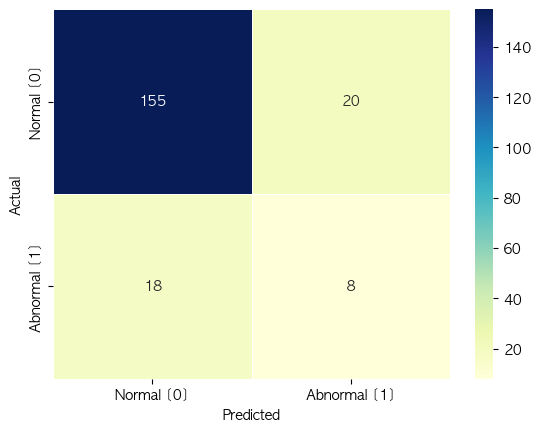

In [199]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score

print(classification_report(y_true=mog_metric['quality'], y_pred=mog_metric['mog_pred'], digits=3))

con_mat = confusion_matrix(mog_metric['quality'], mog_metric['mog_pred'])

sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# IForest

In [200]:
from sklearn.ensemble import IsolationForest

In [202]:
isol = IsolationForest()
isol.fit(X=x_train, y=y_train)

IsolationForest()

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       175
           1       0.09      0.08      0.08        26

    accuracy                           0.78       201
   macro avg       0.48      0.48      0.48       201
weighted avg       0.77      0.78      0.77       201



Text(0.5, 23.52222222222222, 'Predicted')

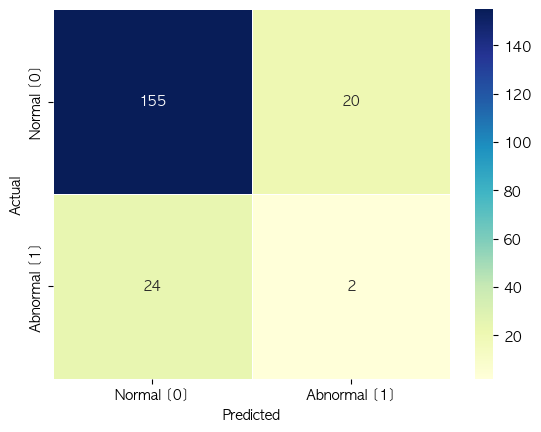

In [203]:
# -1 : anomaly
# 1 : normal
isol_pred_test = isol.predict(x_test)
isol_pred_test = pd.DataFrame(isol_pred_test)
isol_pred_test = isol_pred_test.replace({1:0, -1:1})

print(classification_report(y_true = y_test, y_pred = isol_pred_test))

con_mat = confusion_matrix(y_test, isol_pred_test)
sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# LoF

In [204]:
from sklearn.neighbors import LocalOutlierFactor

              precision    recall  f1-score   support

           0       0.85      0.97      0.91       855
           1       0.21      0.04      0.07       149

    accuracy                           0.83      1004
   macro avg       0.53      0.51      0.49      1004
weighted avg       0.76      0.83      0.78      1004



Text(0.5, 23.52222222222222, 'Predicted')

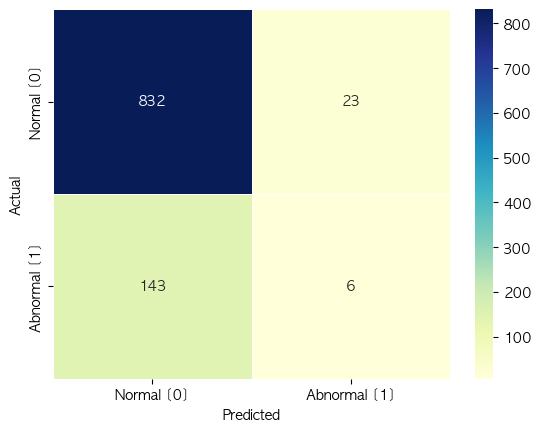

In [205]:
lof = LocalOutlierFactor(novelty=False)

result = lof.fit_predict(X=x, y=y) # y doesnt use in fitting procedure

result = pd.DataFrame(result)
result = result.replace({1:0, -1:1})

print(classification_report(y_true = y , y_pred = result))

con_mat = confusion_matrix(y_true= y, y_pred = result)
sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")
plt.ylabel('Actual')
plt.xlabel('Predicted')

# Auto Encoder

In [206]:
import torch
import torch.nn as nn
import torch.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


class AutoEncoder(nn.Module):
    def __init__(self, input_dim, **kwargs):
        super(AutoEncoder,self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )
        self.decoder = nn.Sequential(
            nn.Linear(1, 4),
            nn.ReLU(),
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim),
            nn.ReLU(),
            nn.Linear(input_dim, input_dim)
        )
    def forward(self, x):
        x = self.encoder(x)
        out = self.decoder(x)
        return out

class WineDataset(Dataset):
    def __init__(self, input:pd.DataFrame, target:pd.DataFrame):
        self.input = torch.tensor(input.values, dtype=torch.float32)
        self.target = torch.tensor(target.values, dtype=torch.float32)
        
    def __len__(self):
        return len(self.input)
    def __getitem__(self, index):
        return self.input[index], self.target[index]

In [207]:
model_config={
    "input_dim" : len(x_train.columns),
    "batch_size" : 32,
    "lr" : 1e-4,
    "loss" : nn.MSELoss(),
    "epoch" : 100
}

train_dataset = WineDataset(x_train_sc, y_train)
test_dataset = WineDataset(x_test_sc, y_test)

train_loader = DataLoader(
    dataset = train_dataset,
    batch_size = model_config['batch_size'],
    shuffle=True
)

test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = model_config['batch_size'],
    shuffle=True
)

model = AutoEncoder(input_dim=model_config['input_dim'])

criterion = model_config["loss"]
optimizer = optim.Adam(model.parameters(), lr=model_config["lr"])

In [73]:
device = torch.device('cpu')

train_losses = []
test_losses = []

for epoch in range(model_config['epoch']):
    model.train()
    train_loss = 0
    test_loss = 0
    
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * inputs.size(0)
    train_epoch_loss = train_loss / len(train_dataset)
    train_losses.append(train_epoch_loss)
    
    with torch.no_grad():    
        model.eval()
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            test_loss += loss.item() * inputs.size(0)
        test_epoch_loss = test_loss / len(test_dataset)
        test_losses.append(test_epoch_loss)
        
    print(f"Epoch [{epoch+1}/{model_config['epoch']}] completed. [Train] Average Loss: {train_epoch_loss:.4f} , [Test] Average Loss : {test_epoch_loss:.4f}")


Epoch [1/100] completed. [Train] Average Loss: 352.9384 , [Test] Average Loss : 302.1631
Epoch [2/100] completed. [Train] Average Loss: 352.6485 , [Test] Average Loss : 301.8958
Epoch [3/100] completed. [Train] Average Loss: 352.3917 , [Test] Average Loss : 301.6973
Epoch [4/100] completed. [Train] Average Loss: 352.2125 , [Test] Average Loss : 301.5357
Epoch [5/100] completed. [Train] Average Loss: 352.0408 , [Test] Average Loss : 301.3726
Epoch [6/100] completed. [Train] Average Loss: 351.8654 , [Test] Average Loss : 301.2033
Epoch [7/100] completed. [Train] Average Loss: 351.6626 , [Test] Average Loss : 300.9815
Epoch [8/100] completed. [Train] Average Loss: 351.4014 , [Test] Average Loss : 300.7187
Epoch [9/100] completed. [Train] Average Loss: 351.1012 , [Test] Average Loss : 300.4200
Epoch [10/100] completed. [Train] Average Loss: 350.7548 , [Test] Average Loss : 300.0652
Epoch [11/100] completed. [Train] Average Loss: 350.3336 , [Test] Average Loss : 299.6338
Epoch [12/100] comp

In [208]:
from tqdm import tqdm

# recent value 
# \*모든 클래스의 조상인 object 클래스
class AverageMeter(object):
    def __init__(self):
        self.reset()
    def reset(self):
        self.avg = 0
        self.val = 0
        self.sum = 0
        self.count = 0
    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def compute_mse(pred,target):
    pass

In [209]:
def train(model_config, dataset, criterion):
    device = torch.device('cpu')
    train_loader = DataLoader(dataset=dataset[0],batch_size=model_config['batch_size'],shuffle=False, drop_last=True)
    test_loader = DataLoader(dataset=dataset[1],batch_size=model_config['batch_size'],shuffle=False, drop_last=True)
    
    model = AutoEncoder(input_dim=model_config['input_dim'])
    model.to(device)
    
    optimizer=optim.Adam(model.parameters(), lr=model_config['lr'])
    
    train_loss, test_loss = AverageMeter(), AverageMeter()
    train_loss_list, test_loss_list = [], []
    best_loss = 0
    
    for epoch in range(1, model_config['epoch']):
        model.train()
        train_bar = tqdm(train_loader) #visualize repeatation part
        train_loss.reset()
        for inputs, targets in train_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            pred = model(inputs)
            loss = criterion(pred, inputs) # audoencoder calculate loss using inputs & pred
            loss.backward()
            optimizer.step()
            train_loss.update(loss.item(), model_config['batch_size'])
            train_bar.set_description(desc=f"{epoch}/{model_config['epoch']} [train] Loss : {train_loss.avg:.6f}")
        train_loss_list.append(train_loss.avg)
    
        test_bar = tqdm(test_loader)
        test_loss.reset()
    
        for inputs, targets in test_bar:
            inputs, targets = inputs.to(device), targets.to(device)
            model.eval()
            with torch.no_grad():
                pred = model(inputs)
                loss = criterion(pred, inputs)
                test_loss.update(loss.item(), model_config['batch_size'])
                test_bar.set_description(desc=f"{epoch}/{model_config['epoch']} [test] Loss : {test_loss.avg:.6f}")
        test_loss_list.append(test_loss.avg)
    return train_loss_list, test_loss_list

In [210]:
train_loss_list, test_loss_list = train(model_config, [train_dataset, test_dataset], criterion=criterion)

99/100 [test] Loss : 0.791097: 100%|██████████| 6/6 [00:00<00:00, 1074.73it/s]


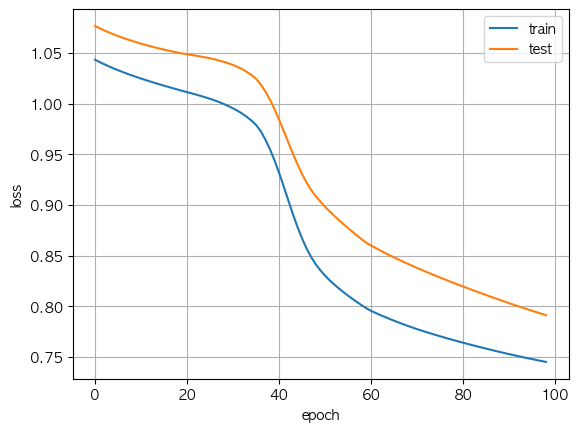

In [211]:
plt.plot(train_loss_list, label='train')
plt.plot(test_loss_list, label='test')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid()

In [212]:
model.eval()

ae_train_pred = model(torch.tensor(x_train_sc.values, dtype=torch.float32))

train_mse = np.mean(np.power(ae_train_pred.detach().numpy() - x_train_sc, 2), axis=1)
threshold = np.percentile( sorted(train_mse), 90)

ae_test_pred = model(torch.tensor(x_test_sc.values, dtype=torch.float32))
test_mse = np.mean(np.power(ae_test_pred.detach().numpy() - x_test_sc, 2), axis=1)


In [214]:
ae_y_pred

,quality,pred
926,0,0
630,0,0
682,0,0
514,0,0
365,0,0
...,...,...
208,0,0
778,0,0
334,0,0
210,0,0


              precision    recall  f1-score   support

           0       0.88      0.90      0.89       175
           1       0.18      0.15      0.17        26

    accuracy                           0.80       201
   macro avg       0.53      0.53      0.53       201
weighted avg       0.79      0.80      0.79       201



<Axes: >

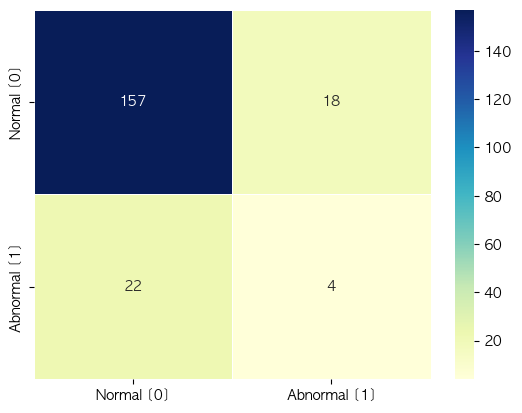

In [226]:
outlier_idx = test_mse[test_mse > threshold].index
ae_y_pred = y_test.copy()
ae_y_pred = pd.DataFrame(ae_y_pred)
ae_y_pred['pred'] = 0
ae_y_pred.loc[out_lier.index, 'pred'] = 1

print(classification_report(y_true=ae_y_pred['quality'],y_pred=ae_y_pred['pred']))

con_mat = confusion_matrix(y_true=ae_y_pred['quality'],y_pred=ae_y_pred['pred'])
sns.heatmap(pd.DataFrame(con_mat, columns = ['Predicted', 'Actual']),
            xticklabels=['Normal [0]', 'Abnormal [1]'], 
            yticklabels=['Normal [0]', 'Abnormal [1]'], 
            annot=True, fmt="d", linewidths=.5, cmap="YlGnBu")

In [184]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [179]:
y_test[outlier_idx]

286    0
388    0
76     1
158    0
294    0
218    0
420    0
174    0
720    0
277    0
Name: quality, dtype: int64

# My Pick : GAN